# Notebook to extract results for the final workshop and the article
Currently based on the copy of the results transferred from Alexa via dropbox

In [1]:
import pandas as pd

In [2]:
# File paths
user_path = '/Users/havardhegre1/python/'
path = user_path + 'prediction_competition_2023/data/' # The folder where the results are stored
overleaf_path = '/Users/havardhegre1/ViEWS Dropbox/Håvard Hegre/Apps/Overleaf/Prediction competition 2023 evaluation article/Results/' # The overleaf project where the results are stored

# Look at the actuals

## From VIEWSER for "new actuals"

In [3]:
# VIEWSER configuration 
# Running from PRIO:
!viewser config set REMOTE_URL https://viewser.viewsforecasting.org
!viewser config set REMOTE_URL http://130.238.55.73/
!viewser config set MODEL_METADATA_DATABASE_HOSTNAME 130.238.55.73

REMOTE_URL: https://viewser.viewsforecasting.org
REMOTE_URL: http://130.238.55.73/
MODEL_METADATA_DATABASE_HOSTNAME: 130.238.55.73


In [4]:
look_at_new_definition = True

if look_at_new_definition:
    # viewser will give the new, evenly disttributed summary event fatalities
    from viewser.operations import fetch
    from viewser import Queryset, Column



    def countrydata():
        qs = (Queryset("country_data_for_evaluation", "country_month")
        .with_column(Column("country_name",from_loa="country",from_column="name"))
        .with_column(Column("isonum",from_loa="country",from_column="isonum"))
        .with_column(Column("isoab",from_loa="country",from_column="isoab"))
        .with_column(Column('ged_sb', from_loa='country_month', from_column='ged_sb_best_sum_nokgi')
            .transform.missing.fill()
            .transform.missing.replace_na()
            )
        )
        data = qs.publish().fetch()
        return(data)
        
    first_month = 457
    last_month = 546

    actuals_df = countrydata().loc[first_month:last_month, :]
    print(actuals_df)

Queryset country_data_for_evaluation read successfully 
                            country_name  isonum isoab  ged_sb
month_id country_id                                           
457      1                        Guyana     328   GUY     0.0
         2                      Suriname     740   SUR     0.0
         3           Trinidad and Tobago     780   TTO     0.0
         4                     Venezuela     862   VEN     0.0
         5                         Samoa     882   WSM     0.0
...                                  ...     ...   ...     ...
546      242                    Tanzania     834   TZA     0.0
         243                     Morocco     504   MAR     0.0
         244                  Mauritania     478   MRT     0.0
         245                       Sudan     729   SDN   285.0
         246                 South Sudan     728   SSD     4.0

[17190 rows x 4 columns]


# Evaluation using both the original actuals and a new set of actuals with summary events fatalities distributed appropriately
## Retrieving the parquet files with evaluation scores, by team, and analysing

In [5]:
# Obtain list of team directories
import os

def list_directories(path):
    """
    Lists all direct subdirectories within the given path.
    """
    directories = []
    for entry in os.listdir(path):
        full_path = os.path.join(path, entry)
        if os.path.isdir(full_path):
            directories.append(entry)
    return directories


In [6]:

#teams_results_directory = path + "/teams/"  # Directory with results for teams with old actuals
#teams_results_directory = path + "/evaluation_metric_cm_new_actuals/"  # Current directory, with corrected actuals
teams_results_directory_oa = path + "evaluation_replication_actuals/"  # Current directory, with corrected actuals
teams_results_directory_na = path + "evaluations_new_actuals/"  # Current directory, with corrected actuals


subdirectories_oa = list_directories(teams_results_directory_oa)
print(f"Directories in '{teams_results_directory_oa}': {subdirectories_oa}")
windows_directory_example = teams_results_directory_oa + subdirectories_oa[0] + '/eval/cm/'
print(f"Example team directory path: {windows_directory_example}")
windows_directories = list_directories(windows_directory_example)
print(f"Subdirectories in example team directory: {windows_directories}")


Directories in '/Users/havardhegre1/python/prediction_competition_2023/data/evaluation_replication_actuals/': ['submission_final_hpmm', 'bodentien_rueter_negbin', 'dorazio_log', 'TW_GAM', 'last', 'conflictology', 'Neg_Bin_GAM', 'unibw_trees_global', 'weighted', 'ShapeFinder', 'P_GLMM', 'submission_final_gpcmm', 'unibw_trees_global-local', 'conflictforecast_v2', 'TW_GLMM', 'evaluation_replication_actuals', 'tft', 'unito_transformer', 'selected', 'dorazio_ensemble', 'zero', 'double_hurdle_model', 'submission_muchlinski_thornhill', 'unweighted', 'Neg_Bin_GLMM', 'submission_final_omm', 'quantile_forecast', 'boot_240', 'hcd_dyad', 'unibw_trees_local', 'conflictology_n', 'evaluations_new_actuals', 'P_GAM']
Example team directory path: /Users/havardhegre1/python/prediction_competition_2023/data/evaluation_replication_actuals/submission_final_hpmm/eval/cm/
Subdirectories in example team directory: ['window=Y2022', 'window=Y2025', 'window=Y2024', 'window=Y2023', 'window=Y2019', 'window=Y2021', 

# Retrieving the actuals for the "old" definition

In [7]:
teams_results_directory_oa

'/Users/havardhegre1/python/prediction_competition_2023/data/evaluation_replication_actuals/'

In [8]:
actuals_path = '/Users/havardhegre1/python/prediction_competition_2023/data/actuals_replication/'
cm_actuals_list = []
pgm_actuals_list = []

for year in [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]:
    file = f'{actuals_path}cm/window=Y{year}/cm_actuals_{year}.parquet'
    print(f'Reading actuals file: {file}')
    cm_actuals_list.append(pd.read_parquet(file))
    file = f'{actuals_path}pgm/window=Y{year}/pgm_actuals_{year}.parquet'
    print(f'Reading actuals file: {file}')
    pgm_actuals_list.append(pd.read_parquet(file))
    
cm_actuals_df = pd.concat(cm_actuals_list)
pgm_actuals_df = pd.concat(pgm_actuals_list)

Reading actuals file: /Users/havardhegre1/python/prediction_competition_2023/data/actuals_replication/cm/window=Y2018/cm_actuals_2018.parquet
Reading actuals file: /Users/havardhegre1/python/prediction_competition_2023/data/actuals_replication/pgm/window=Y2018/pgm_actuals_2018.parquet
Reading actuals file: /Users/havardhegre1/python/prediction_competition_2023/data/actuals_replication/cm/window=Y2019/cm_actuals_2019.parquet
Reading actuals file: /Users/havardhegre1/python/prediction_competition_2023/data/actuals_replication/pgm/window=Y2019/pgm_actuals_2019.parquet
Reading actuals file: /Users/havardhegre1/python/prediction_competition_2023/data/actuals_replication/cm/window=Y2020/cm_actuals_2020.parquet
Reading actuals file: /Users/havardhegre1/python/prediction_competition_2023/data/actuals_replication/pgm/window=Y2020/pgm_actuals_2020.parquet
Reading actuals file: /Users/havardhegre1/python/prediction_competition_2023/data/actuals_replication/cm/window=Y2021/cm_actuals_2021.parquet


In [9]:
cm_actuals_df

outcome
month_id country_id         
457      1               0.0
         2               0.0
         3               0.0
         4               0.0
         5               0.0
...                      ...
546      242             0.0
         243             0.0
         244             0.0
         245           313.0
         246             0.0

[17190 rows x 1 columns]

# Assembling a dataframe with evaluation results
The cell below generates two dataframes, one for cm and one for pgm.
The dataframe are indexed by 

In [10]:
teams_results_directory_oa

'/Users/havardhegre1/python/prediction_competition_2023/data/evaluation_replication_actuals/'

In [11]:
def read_results_from_team(team, team_path):
    """
    Reads results from the given team path.
    """
    window_path = team_path + window + '/metric=' + metric + '/' + metric + '.parquet'
#            print(window_path)
    df = pd.read_parquet(window_path)
    df['team'] = team
    df['window'] = window
    df['metric'] = metric
    
    return df

cm_results_list = []
pgm_results_list = []
for results_directory in [teams_results_directory_oa, teams_results_directory_na]:
    print(f"Processing results directory: {results_directory}")
    subdirectories = list_directories(results_directory)
    print(f"Directories in '{results_directory}': {subdirectories}")
    team_results = []
    first_cm = True
    first_pgm = True
    for team in subdirectories:
        try:
            team_path = results_directory + team + '/eval/cm/'
            print(f"Processing team: {team}, cm, at path: {team_path}")
            for window in windows_directories: # windows_directories are similar for both sets of actuals
                for metric in ['crps', 'ign', 'mis']:
        #        print(team_path)
                    df = read_results_from_team(team, team_path)
                    if first_cm:
                        cm_results = df
                        print(cm_results.head())
                        first_cm = False
                    else:
                        cm_results = pd.concat([cm_results, df], axis=0)    
            print(cm_results.tail())
            print(f'Completed cm results for team {team}')
        except:
            print(f'No cm results for team {team}')
        try:
            team_path = results_directory + team + '/eval/pgm/'
            print(f"Processing team: {team}, pgm, at path: {team_path}")
            for window in windows_directories:
                for metric in ['crps', 'ign', 'mis']:
    #        print(team_path)
                    df = read_results_from_team(team, team_path)
                    if first_pgm:
                        pgm_results = df
                        first_pgm = False
                    else:
                        pgm_results = pd.concat([pgm_results, df], axis=0)
            print(f'Completed pgm results for team {team}')
        except:
            print(f'No pgm results for team {team}')
    cm_results_list.append(cm_results)
    pgm_results_list.append(pgm_results)

Processing results directory: /Users/havardhegre1/python/prediction_competition_2023/data/evaluation_replication_actuals/
Directories in '/Users/havardhegre1/python/prediction_competition_2023/data/evaluation_replication_actuals/': ['submission_final_hpmm', 'bodentien_rueter_negbin', 'dorazio_log', 'TW_GAM', 'last', 'conflictology', 'Neg_Bin_GAM', 'unibw_trees_global', 'weighted', 'ShapeFinder', 'P_GLMM', 'submission_final_gpcmm', 'unibw_trees_global-local', 'conflictforecast_v2', 'TW_GLMM', 'evaluation_replication_actuals', 'tft', 'unito_transformer', 'selected', 'dorazio_ensemble', 'zero', 'double_hurdle_model', 'submission_muchlinski_thornhill', 'unweighted', 'Neg_Bin_GLMM', 'submission_final_omm', 'quantile_forecast', 'boot_240', 'hcd_dyad', 'unibw_trees_local', 'conflictology_n', 'evaluations_new_actuals', 'P_GAM']
Processing team: submission_final_hpmm, cm, at path: /Users/havardhegre1/python/prediction_competition_2023/data/evaluation_replication_actuals/submission_final_hpmm/ev

In [12]:
cm_results_list[0].index.get_level_values(level=0).unique().sort_values()


Int64Index([457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469,
            470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482,
            483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495,
            496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508,
            509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521,
            522, 523, 524, 525, 526, 527, 528, 535, 536, 537, 538, 539, 540,
            541, 542, 543, 544, 545, 546],
           dtype='int64', name='month_id')

In [13]:
cm_results_list[0][cm_results_list[0]['team']=='Neg_Bin_GAM']


value         team        window metric
month_id country_id                                                
505      1           1.000000e-06  Neg_Bin_GAM  window=Y2022   crps
         2           0.000000e+00  Neg_Bin_GAM  window=Y2022   crps
         3           1.000000e-06  Neg_Bin_GAM  window=Y2022   crps
         4           0.000000e+00  Neg_Bin_GAM  window=Y2022   crps
         5           0.000000e+00  Neg_Bin_GAM  window=Y2022   crps
...                           ...          ...           ...    ...
468      242         0.000000e+00  Neg_Bin_GAM  window=Y2018    mis
         243         0.000000e+00  Neg_Bin_GAM  window=Y2018    mis
         244         0.000000e+00  Neg_Bin_GAM  window=Y2018    mis
         245         4.100000e+01  Neg_Bin_GAM  window=Y2018    mis
         246         8.800000e+01  Neg_Bin_GAM  window=Y2018    mis

[48132 rows x 4 columns]

In [14]:
cm_results_list[0]['team'].unique()


array(['submission_final_hpmm', 'bodentien_rueter_negbin', 'TW_GAM',
       'last', 'conflictology', 'Neg_Bin_GAM', 'weighted', 'ShapeFinder',
       'P_GLMM', 'submission_final_gpcmm', 'conflictforecast_v2',
       'TW_GLMM', 'tft', 'unito_transformer', 'selected', 'zero',
       'submission_muchlinski_thornhill', 'unweighted', 'Neg_Bin_GLMM',
       'submission_final_omm', 'quantile_forecast', 'boot_240', 'P_GAM'],
      dtype=object)

In [ ]:
# Renaming models
rename_dict = {
  'submission_final_hpmm': 'Randahl-Vegelius Markov HPMM',
  'bodentien_rueter_negbin': 'Bodentien-Rueter NB',
  'TW_GAM': 'Brandt TW GAM',
  'Neg_Bin_GAM': 'Brandt NB GAM',
  'ShapeFinder': 'PaCE ShapeFinder',
  'P_GLMM': 'Brandt P GLMM',
  'submission_final_gpcmm': 'Randahl-Vegelius Markov GPCMM',
  'conflictforecast_v2': 'ConflictForecast',
  'TW_GLMM': 'Brandt TW GLMM',
  'tft': 'CCEW TFT',
  'submission_muchlinski_thornhill': 'Muchlinski Thornhill zeroinf GAM',
  'Neg_Bin_GLMM': 'Brandt NB GLMM',
  'submission_final_omm': 'Randahl-Vegelius Markov OMM',
  'quantile_forecast': 'Drauz-Becker quantile forecast',   
  'P_GAM': 'Brandt P GAM',
  'boot_240': 'VIEWS BM conflictology bootstrap240',
  'conflictology': 'VIEWS BM conflictology unit12',
  'conflictology_n': 'VIEWS BM conflictology neighbors12',
	'zero': 'VIEWS BM exactly zero',
  'last': 'VIEWS BM last historical',
  'unibw_trees_global': 'CCEW Trees global',
  'unibw_trees_global-local': 'CCEW Trees global local',
	'unibw_trees_local': 'CCEW Trees local',
  'dorazio_ensemble': 'Dorazio Ensemble',
  'dorazio_log': 'Dorazio Log',
  'double_hurdle_model': 'PLY cal double hurdle',
  'hcd_dyad': 'HCD dyad',
  'unito_transformer' : 'UNITO transformer',
  'unweighted': 'Unweighted model ensemble',
  'weighted': 'Weighted model ensemble',
  'selected': 'Selected model ensemble',
}


for cmr in cm_results_list:
    cmr['Model'] = cmr['team'].replace(rename_dict)

for pgmr in pgm_results_list:
    pgmr['Model'] = pgmr['team'].replace(rename_dict)

## Scoreboards
### for true future, with uncorrected and corrected actuals
### Scoreboard for historical periods, with corrected actuals, merged

In [28]:
# Structure to hold results for old and new actuals:
results = [
    {
        'actuals': 'old',
        'cm_results': cm_results_list[0],
        'pgm_results': pgm_results_list[0],
    },
    {
        'actuals': 'new',
        'cm_results': cm_results_list[1],
        'pgm_results': pgm_results_list[1],
    }   
]

In [29]:
pgm_results_list[0]
results[0]['pgm_results']

,month_id,priogrid_gid,value,team,window,metric,Model
0,505,62356,0.0,dorazio_log,window=Y2022,crps,Dorazio_Log
1,505,79599,0.0,dorazio_log,window=Y2022,crps,Dorazio_Log
2,505,79600,0.0,dorazio_log,window=Y2022,crps,Dorazio_Log
3,505,79601,0.0,dorazio_log,window=Y2022,crps,Dorazio_Log
4,505,80317,0.0,dorazio_log,window=Y2022,crps,Dorazio_Log
...,...,...,...,...,...,...,...
46252075,468,190496,0.0,conflictology_n,window=Y2018,mis,VIEWS_bm_conflictology_neighbors12
46252076,468,190507,0.0,conflictology_n,window=Y2018,mis,VIEWS_bm_conflictology_neighbors12
46252077,468,190508,0.0,conflictology_n,window=Y2018,mis,VIEWS_bm_conflictology_neighbors12
46252078,468,190510,0.0,conflictology_n,window=Y2018,mis,VIEWS_bm_conflictology_neighbors12


In [35]:
for result in results:
    print(f"Processing results for actuals: {result['actuals']}")
    try:
        result['cm_results'].reset_index(inplace=True)
    except:
        pass
    cmr = result['cm_results']
    print(cmr.head())
    cmr_woue = cmr[(cmr['country_id'] != 117) & (cmr['country_id'] != 57)] # without Ukraine and Ethiopia 
    result['cm_grouped'] = cmr.groupby(['month_id','Model','metric'])['value'].mean().reset_index() # previously the cm_results_grouped
    result['cm_pivoted'] = result['cm_grouped'].pivot_table(index=['month_id','Model'], columns='metric', values='value').reset_index()
    result['cm_pivoted'].rename(columns={'month_id': 'Month ID', 'Model': 'Model', 'crps': 'CRPS', 'ign': 'ab-Log Score', 'mis': 'MIS'}, inplace=True)
    result['cm_pivoted_hist'] = result['cm_pivoted'][result['cm_pivoted']['Month ID'] < 535]
    result['cm_pivoted_tf'] = result['cm_pivoted'][result['cm_pivoted']['Month ID'] >= 535]
    print(result['cm_pivoted_hist'].tail())
    print(result['cm_pivoted_tf'].tail())
    result['cm_woue_grouped'] = cmr_woue.groupby(['month_id','Model','metric'])['value'].mean().reset_index()
    result['cm_woue_pivoted'] = result['cm_woue_grouped'].pivot_table(index=['month_id','Model'], columns='metric', values='value').reset_index()
    result['cm_woue_pivoted'].rename(columns={'month_id': 'Month ID', 'Model': 'Model', 'crps': 'CRPS', 'ign': 'ab-Log Score', 'mis': 'MIS'}, inplace=True)
    result['cm_woue_pivoted_hist'] = result['cm_woue_pivoted'][result['cm_woue_pivoted']['Month ID'] < 535]
    result['cm_woue_pivoted_tf'] = result['cm_woue_pivoted'][result['cm_woue_pivoted']['Month ID'] >= 535]
    
    try:
        result['pgm_results'].reset_index(inplace=True)
    except:
        pass
    pgmr = result['pgm_results']
    print(pgmr.head())
    result['pgm_grouped'] = pgmr.groupby(['month_id','Model','metric'])['value'].mean().reset_index() # previously the pgm_results_grouped
    result['pgm_pivoted'] = result['pgm_grouped'].pivot_table(index=['month_id','Model'], columns='metric', values='value').reset_index()
    result['pgm_pivoted'].rename(columns={'month_id': 'Month ID', 'Model': 'Model', 'crps': 'CRPS', 'ign': 'ab-Log Score', 'mis': 'MIS'}, inplace=True)
    result['pgm_pivoted_hist'] = result['pgm_pivoted'][result['pgm_pivoted']['Month ID'] < 535]
    result['pgm_pivoted_tf'] = result['pgm_pivoted'][result['pgm_pivoted']['Month ID'] >= 535]
    print(result['pgm_pivoted_hist'].tail())
    print(result['pgm_pivoted_tf'].tail())
    

Processing results for actuals: old
   level_0  index  month_id  country_id     value                   team  \
0        0      0       505           1  0.001234  submission_final_hpmm   
1        1      1       505           2  0.000487  submission_final_hpmm   
2        2      2       505           3  0.000226  submission_final_hpmm   
3        3      3       505           4  0.000735  submission_final_hpmm   
4        4      4       505           5  0.000581  submission_final_hpmm   

         window metric                         Model  
0  window=Y2022   crps  Randahl_Vegelius_markov_hpmm  
1  window=Y2022   crps  Randahl_Vegelius_markov_hpmm  
2  window=Y2022   crps  Randahl_Vegelius_markov_hpmm  
3  window=Y2022   crps  Randahl_Vegelius_markov_hpmm  
4  window=Y2022   crps  Randahl_Vegelius_markov_hpmm  
metric  Month ID                                Model        CRPS  \
1651         528  VIEWS_bm_conflictology_bootstrap240  128.804852   
1652         528     VIEWS_bm_conflicto

In [36]:
# Previeweing the main scoreboard
results[0]['cm_pivoted_tf'].groupby('Model').agg({'CRPS': 'mean', 'ab-Log Score': 'mean', 'MIS': 'mean'}).reset_index().sort_values(by='CRPS', ascending=True)


metric,Model,CRPS,ab-Log Score,MIS
15,Selected model ensemble,2.536773e+01,0.661453,3.474719e+02
19,VIEWS_bm_conflictology_country12,2.549714e+01,0.706311,3.828633e+02
14,Randahl_Vegelius_markov_omm,2.586967e+01,0.649384,3.950420e+02
7,CCEW_tft,2.654713e+01,1.103052,3.818492e+02
2,Brandt_NB_GLMM,2.665701e+01,1.200486,4.194220e+02
8,ConflictForecast,2.678441e+01,0.654167,3.357043e+02
0,Bodentien_Rueter_NB,2.749821e+01,0.679762,4.754182e+02
9,Drauz_Becker_quantile_forecast,2.783793e+01,0.739813,4.766630e+02
21,VIEWS_bm_last_historical,2.817512e+01,1.160745,5.372092e+02
6,Brandt_TW_GLMM,2.823055e+01,0.928786,4.976129e+02


In [37]:
# Create scoreboards for true future and historical periods and save as LaTeX tables, 
# and produce df for use in parallel coordinates plots
# Loop over both actuals sets and both cm and pgm results
for result in results:
    scoreboards_cm = []
    scoreboards_pgm = []
    for level in ['cm', 'pgm']:        
        print(f"Processing {level} results for actuals: {result['actuals']}")
#        results_key = f"{level}_results"
#        pivoted_key = f"{level}_pivoted"
        pivoted_hist_key = f"{level}_pivoted_hist"
        pivoted_tf_key = f"{level}_pivoted_tf"
        
        for metric in ['CRPS', 'ab-Log Score', 'MIS']:
            if metric == 'CRPS':
                models_to_show = 20
            else:
                models_to_show = 10
            
            # Historical period
            scoreboard_hist = result[pivoted_hist_key].groupby('Model').agg({'CRPS': 'mean', 'ab-Log Score': 'mean', 'MIS': 'mean'}).reset_index()
            scoreboard_hist.columns = ['Model', 'CRPS', 'ab-Log Score', 'MIS']
            scoreboard_hist.sort_values(by=metric, ascending=True).head(models_to_show).to_latex(
                f'{overleaf_path}/Tables/{level}_aggregated_scores_hist_by_{metric}_{result["actuals"]}_actuals.tex', 
                index=False,
                formatters={"name": str.upper},
                float_format="{:.2f}".format,)
            scoreboard_hist.columns = ['Model', 'CRPS (hist.)', 'ab-Log Score (hist.)', 'MIS (hist.)']
            if level == 'cm':
                scoreboards_cm.append(scoreboard_hist)
            else:
                scoreboards_pgm.append(scoreboard_hist)

            # True future period
            scoreboard_tf = result[pivoted_tf_key].groupby('Model').agg({'CRPS': 'mean', 'ab-Log Score': 'mean', 'MIS': 'mean'}).reset_index()
            scoreboard_tf.columns = ['Model', 'CRPS', 'ab-Log Score', 'MIS']
            scoreboard_tf.sort_values(by=metric, ascending=True).head(models_to_show).to_latex(
                f'{overleaf_path}/Tables/{level}_aggregated_scores_tf_by_{metric}_{result["actuals"]}_actuals.tex', 
                index=False,
                formatters={"name": str.upper},
            float_format="{:.2f}".format,)
            scoreboard_tf.columns = ['Model (t.f.)', 'CRPS (t.f.)', 'ab-Log Score (t.f.)', 'MIS (t.f.)']
            if level == 'cm':
                scoreboards_cm.append(scoreboard_tf)
            else:
                scoreboards_pgm.append(scoreboard_tf)
    # Combine scoreboards for parallel coordinates plot
    result['joint_scoreboard_cm'] = pd.concat(scoreboards_cm, axis=1)
    result['joint_scoreboard_cm'] = result['joint_scoreboard_cm'].T.drop_duplicates(keep='first').T

    result['joint_scoreboard_pgm'] = pd.concat(scoreboards_pgm, axis=1)
    result['joint_scoreboard_pgm'] = result['joint_scoreboard_pgm'].T.drop_duplicates(keep='first').T
    print("\nDataFrame after dropping duplicate columns (keeping first):")
    print(result['joint_scoreboard_cm'])
    print(result['joint_scoreboard_pgm'])
        
        

Processing cm results for actuals: old


/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:23: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:37: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:23: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formattin

Processing pgm results for actuals: old


/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:23: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:37: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:23: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formattin


DataFrame after dropping duplicate columns (keeping first):
                                  Model     CRPS (hist.) ab-Log Score (hist.)  \
0                   Bodentien_Rueter_NB        56.418956             0.626246   
1                         Brandt_NB_GAM   9460460.074183             0.725604   
2                        Brandt_NB_GLMM       132.465851             1.082139   
3                          Brandt_P_GAM  44311832.833198             2.022537   
4                         Brandt_P_GLMM       112.217208              1.10747   
5                         Brandt_TW_GAM   1585645.054532             1.062203   
6                        Brandt_TW_GLMM       142.156119             0.923131   
7                              CCEW_tft        48.518339             0.742632   
8                      ConflictForecast        47.885964             0.622934   
9        Drauz_Becker_quantile_forecast         55.02268             0.657732   
10     Muchlinski_Thornhill_zeroinf_GAM        4

/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:23: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:37: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:23: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formattin

Processing pgm results for actuals: new


/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:23: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:37: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.

/var/folders/bz/1cx7kmbj2919xmdqxy83mbs80000gp/T/ipykernel_80203/3787990742.py:23: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formattin


DataFrame after dropping duplicate columns (keeping first):
                               Model     CRPS (hist.) ab-Log Score (hist.)  \
0                Bodentien_Rueter_NB        55.926562             0.632738   
1                      Brandt_NB_GAM   9460459.992097             0.728294   
2                     Brandt_NB_GLMM       132.084877             1.087526   
3                       Brandt_P_GAM  44311832.470672             2.030617   
4                      Brandt_P_GLMM       112.027012             1.130379   
5                      Brandt_TW_GAM   1585644.968275             1.062063   
6                     Brandt_TW_GLMM       141.851337             0.937914   
7                           CCEW_tft        48.356584             0.746344   
8                   ConflictForecast          47.4451             0.632077   
9     Drauz_Becker_quantile_forecast        54.587821             0.662499   
10  Muchlinski_Thornhill_zeroinf_GAM        50.511322             1.698719   
11 

In [38]:
results[0]['joint_scoreboard_cm']

,Model,CRPS (hist.),ab-Log Score (hist.),MIS (hist.),CRPS (t.f.),ab-Log Score (t.f.),MIS (t.f.)
0,Bodentien_Rueter_NB,56.418956,0.626246,904.520473,27.498212,0.679762,475.418242
1,Brandt_NB_GAM,9460460.074183,0.725604,186598020.543717,7821334.977577,0.914887,94445109.566296
2,Brandt_NB_GLMM,132.465851,1.082139,2284.928349,26.657008,1.200486,419.421968
3,Brandt_P_GAM,44311832.833198,2.022537,886236551.847262,491706.484479,1.564328,9833777.083399
4,Brandt_P_GLMM,112.217208,1.10747,2223.000993,34.573296,1.191046,668.86082
5,Brandt_TW_GAM,1585645.054532,1.062203,31320346.655835,2163870.25642,1.27616,42661591.932804
6,Brandt_TW_GLMM,142.156119,0.923131,2752.084107,28.230546,0.928786,497.612942
7,CCEW_tft,48.518339,0.742632,848.439143,26.547128,1.103052,381.849218
8,ConflictForecast,47.885964,0.622934,774.736845,26.784408,0.654167,335.704262
9,Drauz_Becker_quantile_forecast,55.02268,0.657732,947.843042,27.837933,0.739813,476.663034


In [33]:

# These are the colors that will be used in the plot
color_sequence_cm = ['#1f77b4', '#2ca02c', '#ffbb78', '#aec7e8', '#ff7f0e',"#060607",
                '#98df8a', '#ff9896', '#9467bd', '#c5b0d5',
                '#8c564b',  '#d62728', '#c49c94', '#e377c2', '#f7b6d2', '#7f7f7f',
                '#c7c7c7', '#bcbd22', '#dbdb8d', '#17becf', '#9edae5']

color_sequence_pgm = ['#1f77b4', "#070707", '#ff7f0e', '#ffbb78', '#2ca02c',
                '#98df8a', '#d62728', '#ff9896', '#9467bd', '#c5b0d5',
                '#8c564b', '#c49c94', '#e377c2', '#f7b6d2', '#7f7f7f',
                '#c7c7c7', '#bcbd22', '#dbdb8d', '#17becf', '#9edae5']

# Some standards
def reduced_model_set(data):
    reduced_data = data.copy()
    reduced_data = reduced_data[reduced_data['Model'] != 'Brandt_P_GAM']
    reduced_data = reduced_data[reduced_data['Model'] != 'Brandt_TW_GAM']
    reduced_data = reduced_data[reduced_data['Model'] != 'Brandt_NB_GAM']
    reduced_data = reduced_data[~reduced_data['Model'].str.contains('VIEWS_bm')]
    reduced_data = reduced_data[reduced_data['Model'].str.contains('model_ensemble') == False]
    return reduced_data
    
    

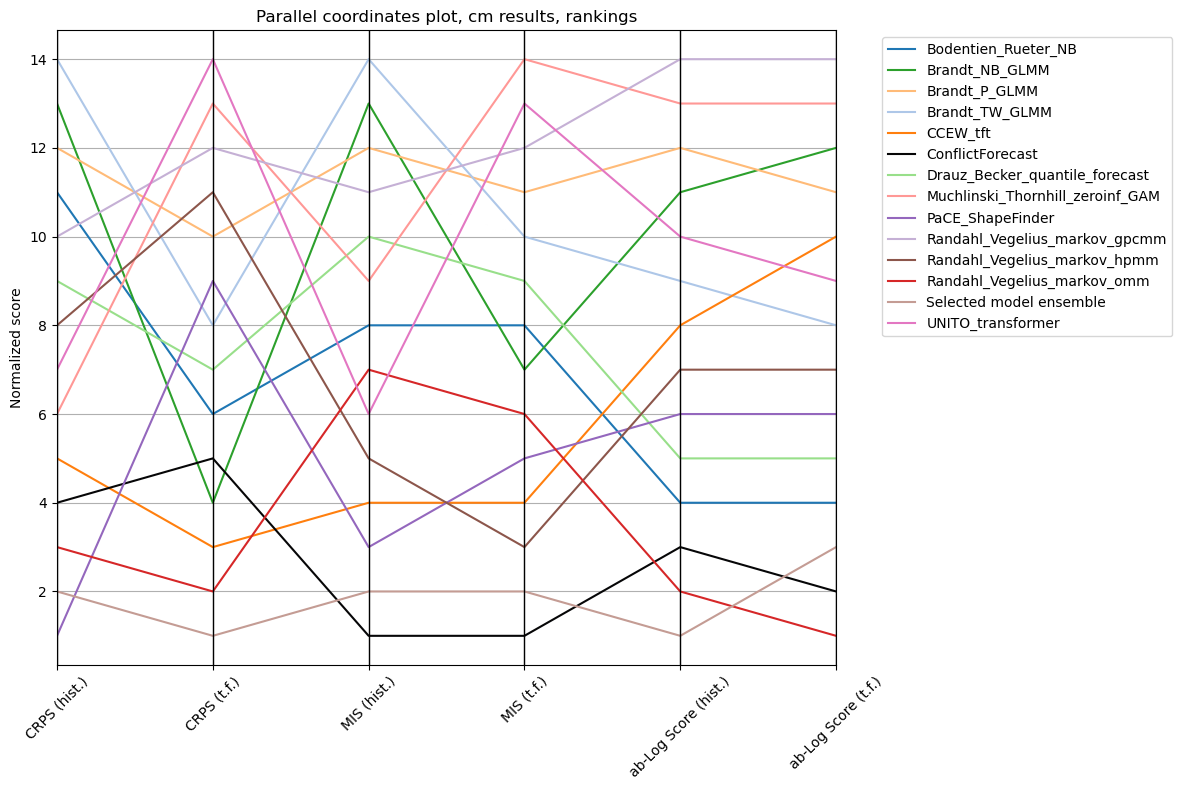

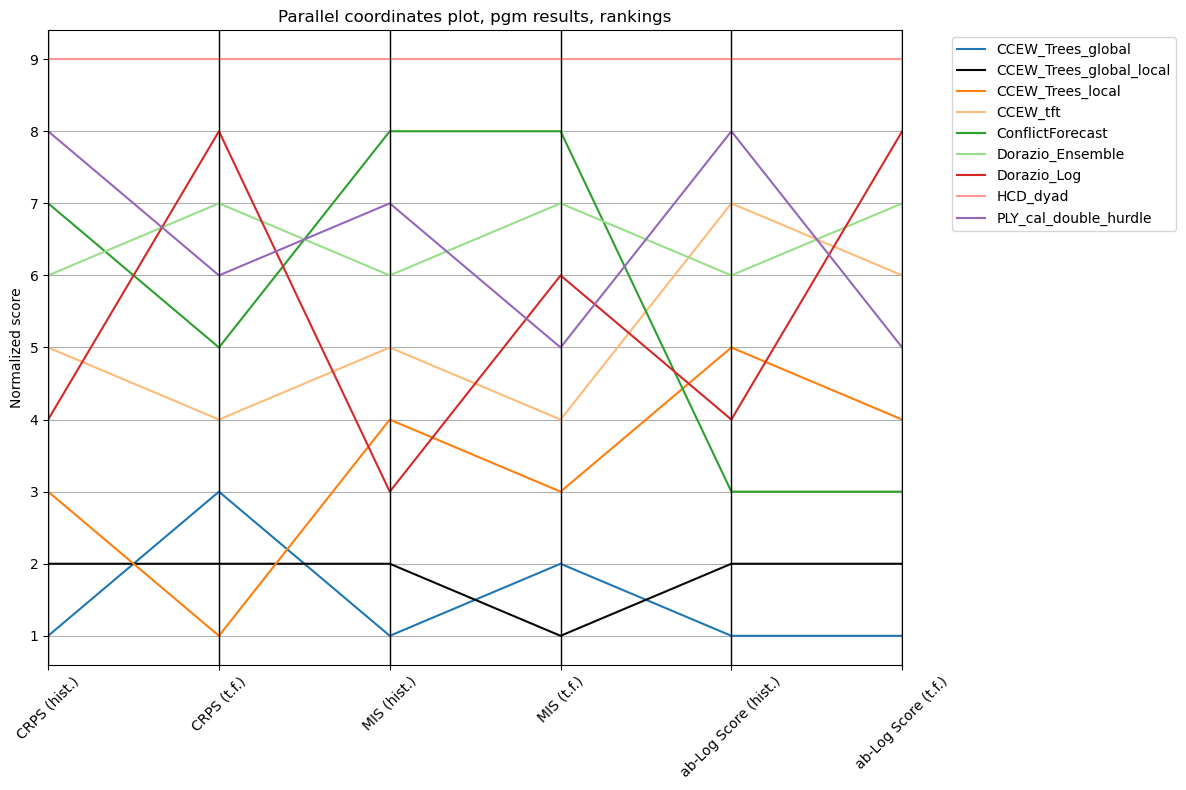

In [34]:
def parallel_coordinates_plot(data, title, save_path, color_sequence):
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    sns.set_palette(sns.color_palette(color_sequence))
    line_widths = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,5,]

    # Remove models Brandt_P_GAM, Brandt_TW_GAM, Brandt_NB_GAM    
    data = reduced_model_set(data)
      
    # Sort columns alphabetically by metric name
    data_sorted = data.sort_index(axis=1)
    data = data_sorted
#    print(data.head())
    # Normalize the scores for better visualization
    score_columns = [col for col in data.columns if col != 'Model']
    for col in score_columns:
        data[col] = (data[col] - data[col].min()) / (data[col].max() - data[col].min())
    # Rank columns
    for col in score_columns:
        data[col] = data[col].rank()    

#    data[score_columns] = (data[score_columns] - data[score_columns].min()) / (data[score_columns].max() - data[score_columns].min())
    
    plt.figure(figsize=(12, 8))
    pd.plotting.parallel_coordinates(data[['Model'] + score_columns], 'Model', color=sns.color_palette(color_sequence))
    plt.title(title)
    plt.ylabel('Normalized score')
    plt.xticks(rotation=45)
    ax = plt.gca()
#    ax.set_yscale('log') # Set the y-axis to a logarithmic scale
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    
for level in ['cm', 'pgm']:
    if level == 'cm':
        joint_scoreboard_df = results[0]['joint_scoreboard_cm']
        color_sequence = color_sequence_cm
    else:
        joint_scoreboard_df = results[0]['joint_scoreboard_pgm']
        color_sequence = color_sequence_pgm

    parallel_coordinates_plot(
        data=joint_scoreboard_df,
    
        title=f'Parallel coordinates plot, {level} results, rankings',
        save_path=f'{overleaf_path}/Figures/parallel_coordinates_{level}.png',
        color_sequence=color_sequence
    )



In [24]:
import plotly.express as px
import pandas as pd
df = pd.DataFrame(dict(
    r=[1, 5, 2, 2, 3],
    theta=['processing cost','mechanical properties','chemical stability',
           'thermal stability', 'device integration']))
fig = px.line_polar(df, r='r', theta='theta', line_close=True)
fig.update_traces(fill='toself')
fig.show()

In [25]:
joint_scoreboard_df['CRPS_historical_normalized'] = (joint_scoreboard_df['CRPS_historical'] - joint_scoreboard_df['CRPS_historical'].min()) / (joint_scoreboard_df['CRPS_historical'].max() - joint_scoreboard_df['CRPS_historical'].min())
joint_scoreboard_df


KeyError: 'CRPS_historical'

In [ ]:
# Plot scores by month for all models
import matplotlib.pyplot as plt
import seaborn as sns
def readable_month(month):
    year = month/12 + 1980
    month_in_year = (month % 12)
    return f'{int(month_in_year):02d}-{int(year)}'
def readable_year(month):
    if month % 12 == 0 or month % 12 == 6:
        year = month/12 + 1980
        month_in_year = (month % 12)
        return f'{int(month_in_year):02d}-{int(year)}'
    else:
        return ''

def plot_scores_by_month(data, metric, period, color_sequence):
    # Determine label based on period
    if data.equals(result['cm_pivoted_hist']):
        label = 'historical'
    elif data.equals(result['cm_pivoted_tf']):
        label = 'true_future'
    else:
        label = 'combined'
    data = reduced_model_set(data)
    sns.set_palette(sns.color_palette(color_sequence))
    plt.figure(figsize=(12, 8))
    sns.lineplot(data=data, x='Month ID', y=metric, hue='Model', palette=color_sequence, marker='o')
    plt.title(f'{metric} by month for all models, {period} period, old actuals')
    plt.xticks(rotation=45)
    plt.ylabel(metric)
    if period == 'true_future':
        plt.xticks(ticks=data['Month ID'], labels=[readable_month(m) for m in data['Month ID']])
    else:
        plt.xticks(ticks=data['Month ID'], labels=[readable_year(m) for m in data['Month ID']])
    ax = plt.gca()
    ax.set_yscale('log') # Set the y-axis to a logarithmic scale
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'{overleaf_path}/Figures/{metric.lower().replace(" ", "_")}_by_month_all_models_cm_{label}.png')
    plt.show()

for period in ['historical', 'true_future', 'combined']:
    for level in ['cm', 'pgm']:
        if level == 'cm':
            color_sequence = color_sequence_cm
        else:
            color_sequence = color_sequence_pgm
        if period == 'historical':
            period_def = results[0][f'{level}_pivoted_hist']
        elif period == 'true_future':
            period_def = results[0][f'{level}_pivoted_tf']
        else:
            period_def = pd.concat([results[0][f'{level}_pivoted_hist'], results[0][f'{level}_pivoted_tf']])
        for metric in ['CRPS', 'ab-Log Score', 'MIS']:
            plot_scores_by_month(period_def, metric, period, color_sequence)

# Most influential/difficult cases 

In [ ]:
results[0]['cm_results']

In [ ]:
results[0]['cm_results'].metric.unique()

In [ ]:
# Identify country months where the average model perform the worst, per metric and period
# Only for the old actuals 
cm_results_hist = results[0]['cm_results'][results[0]['cm_results']['month_id'] < 535]
cm_results_tf = results[0]['cm_results'][results[0]['cm_results']['month_id'] >= 535]

for period_def in [cm_results_hist, cm_results_tf]:
    data = period_def.copy()
    for metric in ['crps', 'ign', 'mis']:
        data = data[data['team'] != 'P_GAM']
        data = data[data['team'] != 'TW_GAM']
        data = data[data['team'] != 'Neg_Bin_GAM']
#        print(data.head())
        worst_cms = data.groupby(['month_id', 'country_id', 'metric']).agg({'value': 'mean'}).reset_index()
        if period_def.equals(cm_results_hist):
            period = 'historical'
        else:
            period = 'true_future'
        print(f'Worst countries for metric {metric} in period {period}:'  )
        print(worst_cms[worst_cms['metric'] == metric].sort_values(by='value', ascending=False).head(20))

In [ ]:
cm_actuals_df

In [ ]:
cm_actuals_df_woi = cm_actuals_df.reset_index()
for country in [57,65, 94, 117, 128, 167, 218, 245]:
    print(cm_actuals_df_woi[cm_actuals_df_woi['country_id']== country].head(1))
print('Ethiopia actuals, top 10:')
print(cm_actuals_df_woi[cm_actuals_df_woi['country_id']== 57].sort_values(by='outcome',ascending=False).head(10))

In [ ]:
# Find out where all models struggled in the 2018--2024 period
cm_results_historical = cm_results[cm_results['month_id'] < 535]
# Exclude Brandt's GAM models
cm_results_historical = cm_results_historical[cm_results_historical['Model'] != 'Brandt_P_GAM']
cm_results_historical = cm_results_historical[cm_results_historical['Model'] != 'Brandt_TW_GAM']
cm_results_historical = cm_results_historical[cm_results_historical['Model'] != 'Brandt_NB_GAM']

worst_cms = cm_results_historical.groupby(['month_id', 'country_id', 'metric']).agg({'value': 'mean'}).reset_index()
worst_cms[worst_cms['metric'] == 'crps'].sort_values(by='value', ascending=False).head(30)

### Parallel coordinates plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates
import io
import requests

# 1. Load the data (using a sample URL for demonstration)
url = "raw.githubusercontent.com"
df = pd.read_csv(url)

# 2. Create the parallel coordinates plot
# 'species' is the column used to color the different lines
plt.figure(figsize=(10, 6))
parallel_coordinates(df, 'species', colormap=plt.cm.Dark2)

# 3. Customize the plot
plt.title('Parallel Coordinates Plot of the Iris Dataset')
plt.xlabel('Features')
plt.ylabel('Value (normalized across features)')
plt.legend(loc='upper right')
plt.grid(True)

# 4. Display the plot
plt.show()

In [ ]:
# Aggregating results by team and window
aggregated_cm_results = cm_results_tf.groupby(['team', 'window', 'metric']).agg({'value': 'mean'}).reset_index()
aggregated_pgm_results = pgm_results.groupby(['team', 'window', 'metric']).agg({'value': 'mean'}).reset_index()

In [ ]:
aggregated_cm_results_2024 = aggregated_cm_results[aggregated_cm_results['window'] == 'window=Y2024']
aggregated_cm_results_2024[aggregated_cm_results_2024['metric'] == 'crps'].sort_values(by='value', ascending=True) 
#aggregated_cm_results_2024.head(20)

In [ ]:
cm_results.head()